# B9.2 Wave Packets
<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## B9.2.1 Motivation: Why Wave Packets?

### Real Particles Are Not Infinite Waves

So far, we have described matter as if it were a single, perfect wave extending infinitely through space.  
But no real particle behaves like that — real particles are **localized**, and we need a description that tells us **where** a particle is likely to be.

---

### Building a Localized Wave

A single wave cannot describe a localized particle.  
Instead, we must combine **many different waves** to form a short "pulse" or **wave packet**.

Think of how a sharp sound or a musical beat is formed by mixing many different notes — the same idea applies to matter waves.

---

### Position vs Momentum

There is a trade-off:

- A very localized wave packet requires **many different wave components**, meaning the particle’s momentum becomes uncertain.  
- A perfectly single wave has **only one momentum** but is spread out everywhere.

This is the physical reason behind the **Heisenberg Uncertainty Principle**.

---

### Why Learn It Now?

Wave packets are our first step toward describing **real particles**:

- They let us discuss where a particle is likely to be found.  
- They naturally connect to **probability**, **uncertainty**, and later to the **Schrödinger equation**.

Understanding wave packets changes matter waves from an abstract idea into something we can actually use to describe experiments.

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## B9.2.2 de Broglie Hypothesis → Matter Waves

In 1924, Louis de Broglie proposed that **particles exhibit wave-like behavior**:

$$
\lambda = \frac{h}{p}
$$

Equivalently:

- **Wavenumber**: 

$$
k = \frac{2\pi}{\lambda} = \frac{p}{\hbar}
$$

- **Frequency (via energy)**:  
For a non-relativistic particle:

$$
E = \frac{p^2}{2m} \quad \Rightarrow \quad \omega = \frac{E}{\hbar} = \frac{\hbar k^2}{2m}
$$

Thus, a free particle of momentum $p$ can be associated with a **matter wave** of wavenumber $k$ and frequency $\omega$.

---

### Representing a Matter Wave

A natural way to represent a periodic wave is with a sinusoid or complex exponential:

$$
\psi(x,t) = A e^{i(kx - \omega t)}
$$

This is the simplest mathematical form that has:
- Wavelength $ \lambda = 2\pi/k $
- Oscillation in time with frequency $\omega$
- Definite momentum $p = \hbar k$ and definite energy $E = \hbar \omega$

However:

⚠️ **A single de Broglie wave extends infinitely in space**.  
It has a perfectly defined wavelength (momentum), but no well-defined location.  

Real particles are detected in some region of space, so we need to build a **localized wave packet** by combining many such waves.

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## B9.2.3 From Plane Waves to Wave Packets

### Why a Single Wave is Not Enough

- A single wave corresponds to a **perfectly defined momentum**.
- But because it stretches uniformly across all space, it cannot describe a particle found in a limited region.

---

### Constructing a Wave Packet

A **wave packet** is formed as a superposition of many different $k$ components:

$$
\Psi(x,t) = \frac{1}{\sqrt{2\pi}} \int_{-\infty}^{\infty} \phi(k)\, e^{i(kx - \omega t)} \, dk
$$

- $\phi(k)$ describes how much of each $k$ contributes to the packet.
- A **broader range of $k$ values** → **narrower** (more localized) packet in $x$.
- A **narrow range of $k$ values** → **more spread out** packet in $x$.

This is an example of a general Fourier principle: sharp localization in one variable requires many components in the conjugate variable.

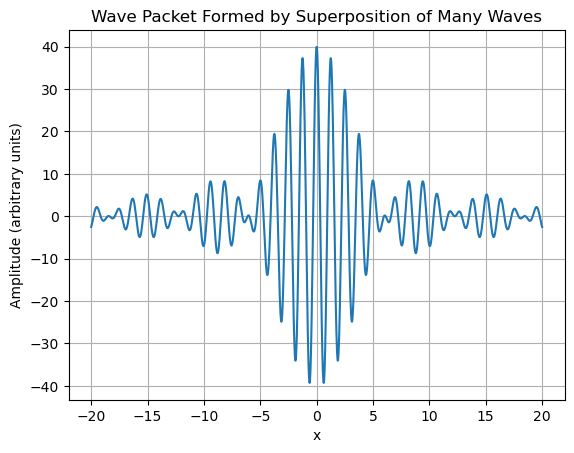

In [11]:
%reset -f 
# --- Visualization: Building a Wave Packet ---
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-20, 20, 2000)
k_values = np.linspace(4.5, 5.5, 40)  # range of k around k0 ~ 5
psi = sum(np.cos(k * x) for k in k_values)

plt.plot(x, psi)
plt.title("Wave Packet Formed by Superposition of Many Waves")
plt.xlabel("x")
plt.ylabel("Amplitude (arbitrary units)")
plt.grid(True)
plt.show()

### Interpretation

- The packet is concentrated near $x=0$.
- Adding more $k$ components (larger $\Delta k$) makes the packet even sharper.

This **localization–momentum spread trade-off** will lead us naturally to the **uncertainty principle** in the next topic.

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## B9.2.4 Group Velocity vs Phase Velocity

### Definitions

For a single component $e^{i(kx - \omega t)}$:

- **Phase velocity**:  

$$
v_{\text{phase}} = \frac{\omega}{k}
$$

- **Group velocity** (velocity of the packet’s envelope):  

$$
v_{\text{group}} = \frac{d\omega}{dk}
$$

The **group velocity** corresponds to the particle’s actual motion.

---

### Group Velocity for Matter Waves

For a free particle:

$$
\omega = \frac{\hbar k^2}{2m}
$$

So:

$$
v_{\text{group}} = \frac{d\omega}{dk} = \frac{\hbar k}{m} = \frac{p}{m} = v_{\text{particle}}
$$

✔️ **Group velocity equals the classical particle velocity.**

The phase velocity:

$$
v_{\text{phase}} = \frac{\omega}{k} = \frac{\hbar k}{2m} = \frac{v_{\text{particle}}}{2}
$$

does not represent the particle’s physical speed.

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## B9.2.5 Localization and Momentum Spread

### Position–Momentum Trade-Off

Fourier analysis tells us:

$$
\Delta x \, \Delta k \sim 1
$$

Using $p = \hbar k$:

$$
\Delta x \, \Delta p \sim \hbar
$$

- Small $\Delta x$ (high localization) → large $\Delta p$ (high momentum spread)
- Large $\Delta x$ → small $\Delta p$

This is the foundation of the **Heisenberg Uncertainty Principle** we’ll study next.

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

### Visualizing the Trade-Off

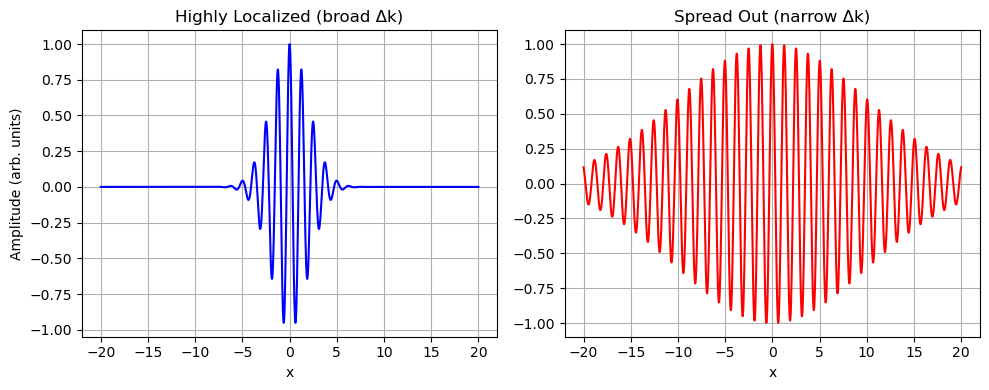

In [10]:
%reset -f
import numpy as np
import matplotlib.pyplot as plt

def wave_packet(x, k0, sigma_k):
    """Simple Gaussian-like packet in k-space approximated in x-space."""
    return np.exp(-x**2 * sigma_k**2 / 2) * np.cos(k0 * x)

x = np.linspace(-20, 20, 2000)

psi_localized = wave_packet(x, k0=5, sigma_k=0.5)
psi_spread = wave_packet(x, k0=5, sigma_k=0.1)

# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(10,4))

# Left: Highly localized packet
axes[0].plot(x, psi_localized, color='b')
axes[0].set_title("Highly Localized (broad Δk)")
axes[0].set_xlabel("x")
axes[0].set_ylabel("Amplitude (arb. units)")
axes[0].grid(True)

# Right: Spread-out packet
axes[1].plot(x, psi_spread, color='r')
axes[1].set_title("Spread Out (narrow Δk)")
axes[1].set_xlabel("x")
axes[1].grid(True)

plt.tight_layout()
plt.show()


## B9.2.6 Summary

- **Single de Broglie waves** describe definite momentum but no definite position.
- **Wave packets** are superpositions of many $k$ values, allowing localization.
- **Group velocity = particle velocity.**
- Localizing a particle more tightly requires adding more $k$ components → increases momentum spread.
- This trade-off leads directly to the **Heisenberg Uncertainty Principle**.

<hr style="height:2px;border-width:0;color:gray;background-color:gray">